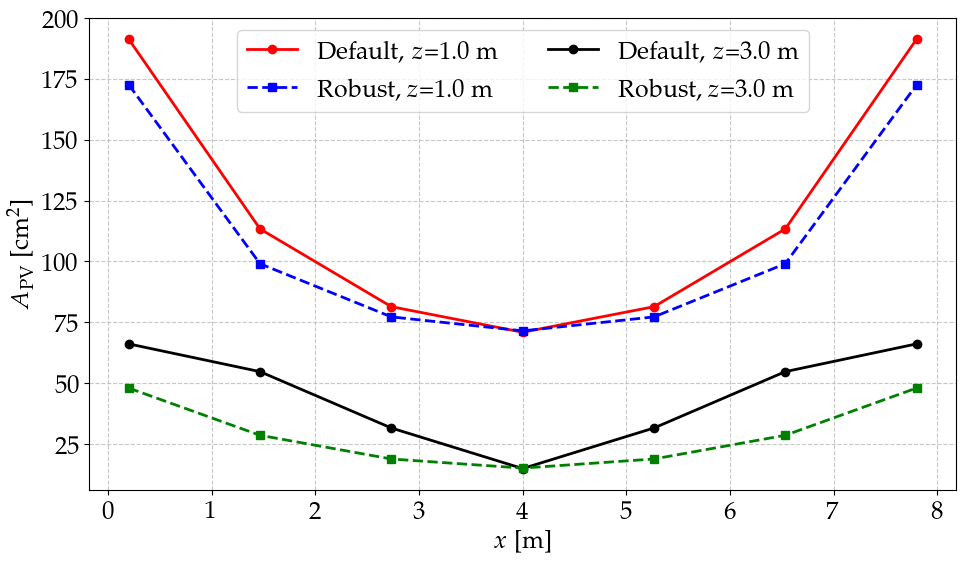

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# 1. Load results
results_nom = np.load("area_only_cma_results_C_eight.npy", allow_pickle=True)
results_rob = np.load("robust_minimax_results_C.npy") 

# 2. Extract X, Z coordinates, and areas
x_coords_nom = np.array([res['pos'][0] for res in results_nom])
z_coords_nom = np.array([res['pos'][2] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

x_coords_rob = results_rob[:, 0]
z_coords_rob = results_rob[:, 2]
areas_rob = results_rob[:, 5] * 1e4  # m² -> cm²

# 3. Unique heights
unique_zs = np.unique(z_coords_nom)

# 4. Define exactly four colors
colors = ["red", "blue", "black", "green"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, z_val in enumerate(unique_zs):
    # Pick colors cycling through the four
    color_nom = colors[(2*i) % 4]    # nominal curve
    color_rob = colors[(2*i + 1) % 4]  # robust curve
    
    # Nominal
    mask_nom = (z_coords_nom == z_val)
    x_nom_z = x_coords_nom[mask_nom]
    areas_nom_z = areas_nom[mask_nom]
    sort_idx_nom = np.argsort(x_nom_z)
    
    ax.plot(x_nom_z[sort_idx_nom], areas_nom_z[sort_idx_nom],
            marker='o', linestyle='-', color=color_nom,
            linewidth=2, label=f'Default, $z$={z_val} m')
    
    # Robust
    mask_rob = (z_coords_rob == z_val)
    x_rob_z = x_coords_rob[mask_rob]
    areas_rob_z = areas_rob[mask_rob]
    sort_idx_rob = np.argsort(x_rob_z)
    
    ax.plot(x_rob_z[sort_idx_rob], areas_rob_z[sort_idx_rob],
            marker='s', linestyle='--', color=color_rob,
            linewidth=2, label=f'Robust, $z$={z_val} m')

ax.set_xlabel(r'$x$ [m]')
ax.set_ylabel(r'$A_\mathrm{PV}$ [cm$^2$]')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(ncol=2)

plt.tight_layout()
plt.savefig("area_C.pdf")
plt.show()

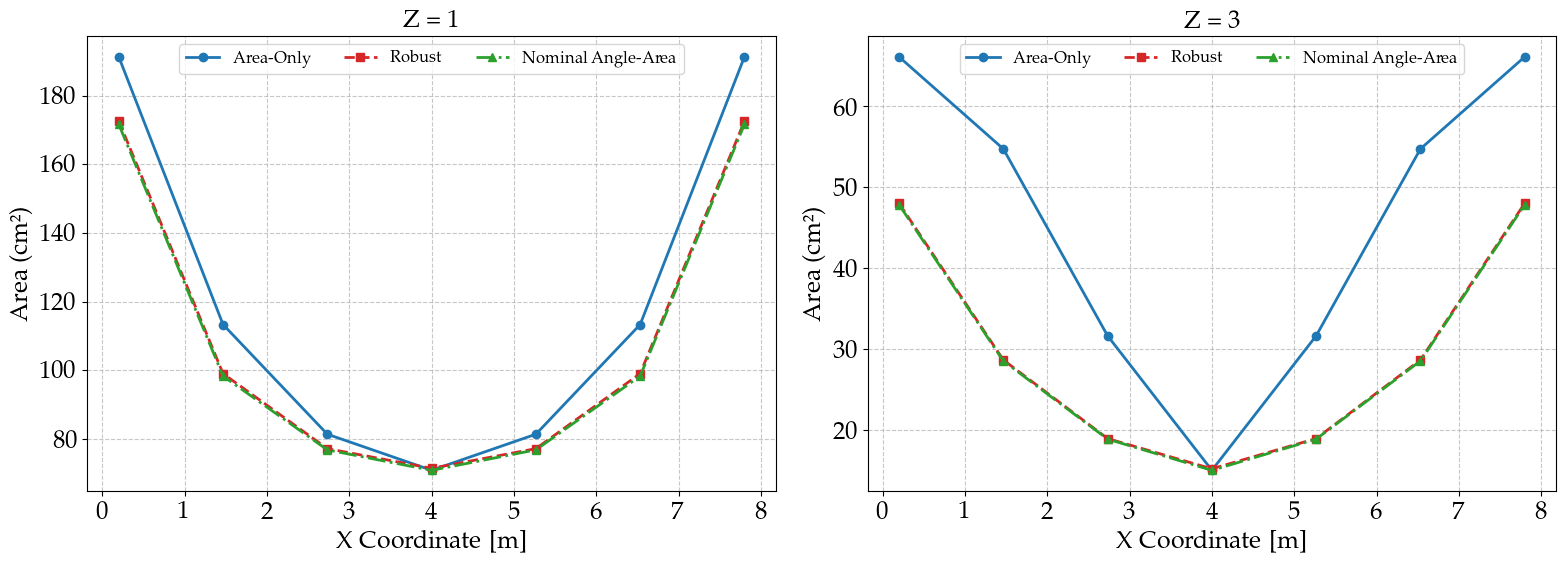

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

# Load results
results_area_only = np.load("area_only_cma_results_C_eight.npy", allow_pickle=True)
results_robust = np.load("robust_minimax_results_C.npy")
results_nom_angle = np.load("cma_simple_C_eight.npy", allow_pickle=True)

# Extract coordinates and areas
x_area = np.array([res['pos'][0] for res in results_area_only])
z_area = np.array([res['pos'][2] for res in results_area_only])
areas_area = np.array([res['area_cm2'] for res in results_area_only])

x_rob = results_robust[:, 0]
z_rob = results_robust[:, 2]
areas_rob = results_robust[:, 5] * 1e4

x_nom = np.array([res['pos'][0] for res in results_nom_angle])
z_nom = np.array([res['pos'][2] for res in results_nom_angle])
areas_nom = np.array([res['area_cm2'] for res in results_nom_angle])

# Heights to plot
zs_to_plot = [1, 3]

colors = {'area_only': 'tab:blue', 'robust': 'tab:red', 'nom_angle': 'tab:green'}
markers = {'area_only': 'o', 'robust': 's', 'nom_angle': '^'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # No shared y-axis

for ax, z_val in zip(axes, zs_to_plot):
    # Area-only
    mask = z_area == z_val
    x_plot = x_area[mask]
    y_plot = areas_area[mask]
    sort_idx = np.argsort(x_plot)
    ax.plot(x_plot[sort_idx], y_plot[sort_idx],
            marker=markers['area_only'], linestyle='-',
            color=colors['area_only'], linewidth=2, label='Area-Only')

    # Robust
    mask = z_rob == z_val
    x_plot = x_rob[mask]
    y_plot = areas_rob[mask]
    sort_idx = np.argsort(x_plot)
    ax.plot(x_plot[sort_idx], y_plot[sort_idx],
            marker=markers['robust'], linestyle='--',
            color=colors['robust'], linewidth=2, label='Robust')

    # Nominal angle-area
    mask = z_nom == z_val
    x_plot = x_nom[mask]
    y_plot = areas_nom[mask]
    sort_idx = np.argsort(x_plot)
    ax.plot(x_plot[sort_idx], y_plot[sort_idx],
            marker=markers['nom_angle'], linestyle='-.',
            color=colors['nom_angle'], linewidth=2, label='Nominal Angle-Area')

    ax.set_xlabel('X Coordinate [m]', fontsize=18, fontweight='bold')
    ax.set_ylabel('Area (cm²)', fontsize=18, fontweight='bold')
    ax.set_title(f'Z = {z_val}', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper center', fontsize=12, ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
(areas_nom - areas_rob)/areas_nom * 100

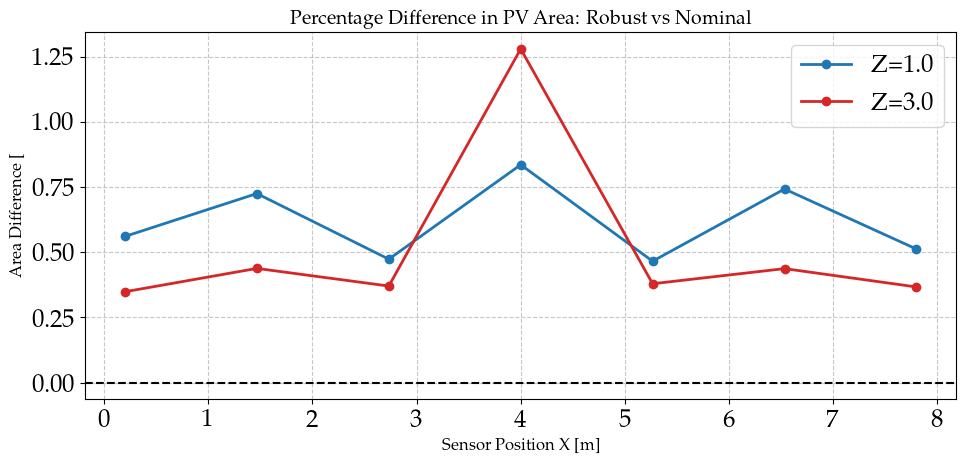

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Nominal CMA (Area)
# ==========================================
data_nom = np.load("cma_simple_C_eight.npy", allow_pickle=True)
x_nom = np.array([d['pos'][0] for d in data_nom])
z_nom = np.array([d['pos'][2] for d in data_nom])
area_nom = np.array([d['area_cm2'] for d in data_nom])

# ==========================================
# 2. Load Robust Optimization (Area)
# ==========================================
data_rob = np.load("robust_minimax_results_C.npy")
x_rob = data_rob[:, 0]
z_rob = data_rob[:, 2]
area_rob = data_rob[:, 5] * 1e4  # convert m² -> cm²

# ==========================================
# 3. Unique heights (Z)
# ==========================================
unique_zs = np.unique(z_nom)
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple']

plt.figure(figsize=(10, 5))

for i, z_val in enumerate(unique_zs):
    color = colors[i % len(colors)]
    
    # Nominal mask
    mask_nom = z_nom == z_val
    x_nom_z = x_nom[mask_nom]
    area_nom_z = area_nom[mask_nom]
    
    # Robust mask
    mask_rob = z_rob == z_val
    x_rob_z = x_rob[mask_rob]
    area_rob_z = area_rob[mask_rob]
    
    # Sort by X for proper plotting
    sort_nom = np.argsort(x_nom_z)
    sort_rob = np.argsort(x_rob_z)
    
    # Percentage difference
    area_diff = ((area_rob_z[sort_rob] - area_nom_z[sort_nom]) / area_nom_z[sort_nom]) * 100
    
    # Plot
    plt.plot(x_nom_z[sort_nom], area_diff, marker='o', linestyle='-', color=color, label=f'Z={z_val}')

# Zero baseline
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Labels & formatting
plt.title('Percentage Difference in PV Area: Robust vs Nominal', fontsize=14, fontweight='bold')
plt.xlabel('Sensor Position X [m]', fontsize=12)
plt.ylabel('Area Difference [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

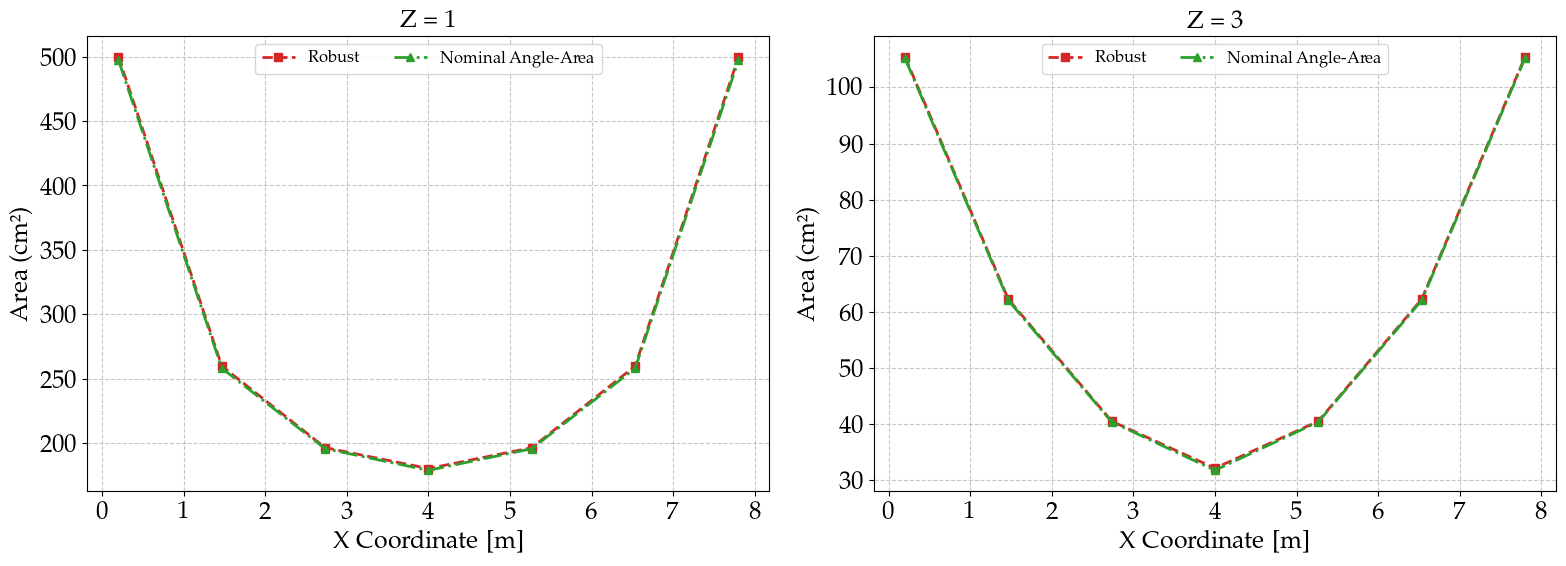

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load results
results_robust = np.load("optimization_result_C.npy")
results_nom_angle = np.load("cma_simple_C.npy", allow_pickle=True)

# Extract coordinates and areas
x_rob = results_robust[:, 0]
z_rob = results_robust[:, 2]
areas_rob = results_robust[:, 5] * 1e4  # m² → cm²

x_nom = np.array([res['pos'][0] for res in results_nom_angle])
z_nom = np.array([res['pos'][2] for res in results_nom_angle])
areas_nom = np.array([res['area_cm2'] for res in results_nom_angle])

# Heights to plot
zs_to_plot = [1, 3]

colors = {'robust': 'tab:red', 'nom_angle': 'tab:green'}
markers = {'robust': 's', 'nom_angle': '^'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, z_val in zip(axes, zs_to_plot):

    # Robust
    mask = z_rob == z_val
    x_plot = x_rob[mask]
    y_plot = areas_rob[mask]
    sort_idx = np.argsort(x_plot)
    ax.plot(x_plot[sort_idx], y_plot[sort_idx],
            marker=markers['robust'], linestyle='--',
            color=colors['robust'], linewidth=2, label='Robust')

    # Nominal angle-area
    mask = z_nom == z_val
    x_plot = x_nom[mask]
    y_plot = areas_nom[mask]
    sort_idx = np.argsort(x_plot)
    ax.plot(x_plot[sort_idx], y_plot[sort_idx],
            marker=markers['nom_angle'], linestyle='-.',
            color=colors['nom_angle'], linewidth=2, label='Nominal Angle-Area')

    ax.set_xlabel('X Coordinate [m]', fontsize=18, fontweight='bold')
    ax.set_ylabel('Area (cm²)', fontsize=18, fontweight='bold')
    ax.set_title(f'Z = {z_val}', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper center', fontsize=12, ncol=2)

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# Load data
results_robust = np.load("robust_minimax_results_C.npy")
results_nom_angle = np.load("cma_simple_C_eight.npy", allow_pickle=True)

# Extract robust
x_rob = results_robust[:, 0]
z_rob = results_robust[:, 2]
areas_rob = results_robust[:, 5] * 1e4  # m² → cm²

# Extract nominal
x_nom = np.array([res['pos'][0] for res in results_nom_angle])
z_nom = np.array([res['pos'][2] for res in results_nom_angle])
areas_nom = np.array([res['area_cm2'] for res in results_nom_angle])

# Build dictionaries keyed by (x,z)
rob_dict = {(x_rob[i], z_rob[i]): areas_rob[i] for i in range(len(x_rob))}
nom_dict = {(x_nom[i], z_nom[i]): areas_nom[i] for i in range(len(x_nom))}

# Compare
all_smaller = True
violations = []

for key in nom_dict:
    if key in rob_dict:
        if not (nom_dict[key] < rob_dict[key]):
            all_smaller = False
            violations.append((key, nom_dict[key], rob_dict[key]))

if all_smaller:
    print("Nominal area is smaller than robust for ALL matching points.")
else:
    print("Found points where nominal is NOT smaller than robust:")
    for v in violations:
        print(f"(x,z)={v[0]} | nominal={v[1]:.4f} cm² | robust={v[2]:.4f} cm²")

Nominal area is smaller than robust for ALL matching points.


In [9]:
(areas_rob - areas_nom)/areas_nom * 100

array([0.5608261 , 0.72525526, 0.47351981, 0.83578793, 0.46575818,
       0.74263828, 0.51235358, 0.3486236 , 0.43811588, 0.37047013,
       1.28015424, 0.37929226, 0.43734557, 0.36699007])

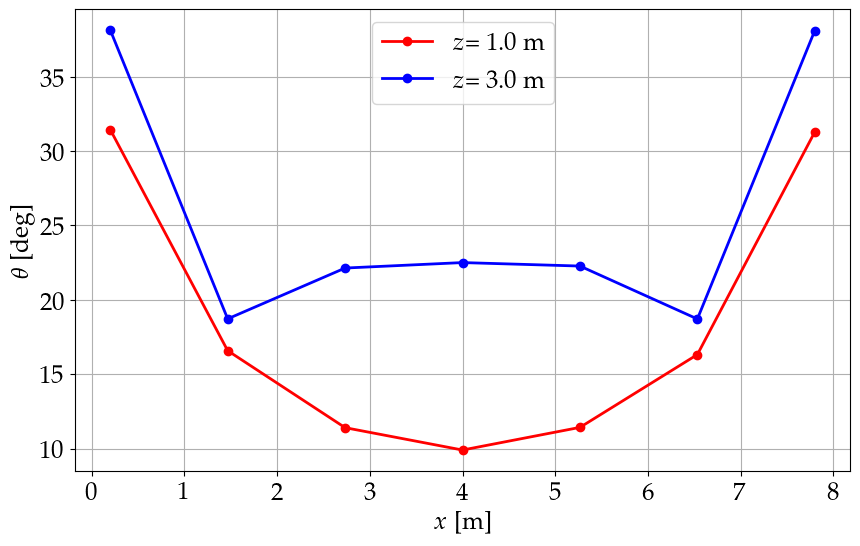

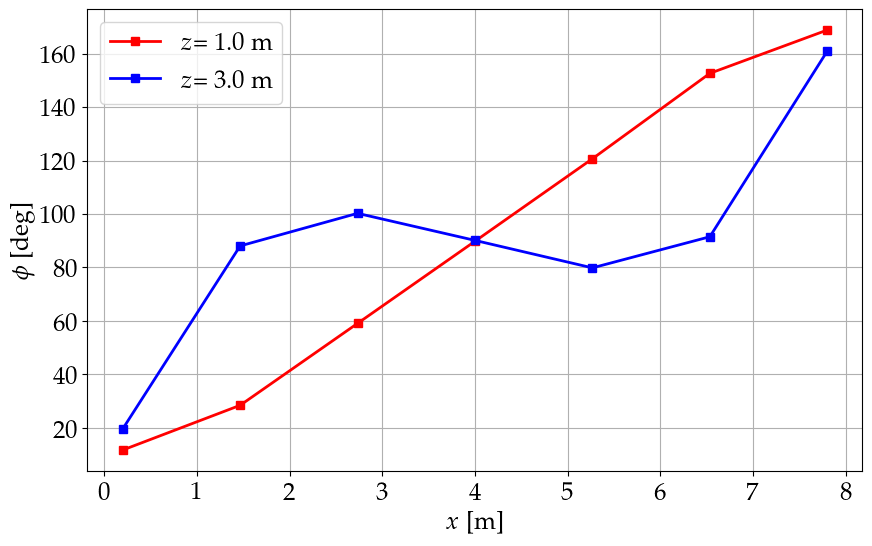

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Load robust results
results_robust = np.load("robust_minimax_results_C.npy")
# Columns: [X,Y,Z,Theta, Phi, Area, Cost]

# Extract variables
x = results_robust[:,0]
z = results_robust[:,2]
theta = np.degrees(results_robust[:,3])
phi = np.degrees(results_robust[:,4])

unique_z = np.unique(z)

# Assign simple colors (edit these if you want)
colors = ['red', 'blue', 'green', 'black', 'orange', 'purple']

# -------- Theta Plot --------
plt.figure(figsize=(10,6))

for i, z_val in enumerate(unique_z):
    
    mask = z == z_val
    idx = np.argsort(x[mask])
    
    x_sorted = x[mask][idx]
    theta_sorted = theta[mask][idx]
    
    plt.plot(x_sorted, theta_sorted,
             marker='o',
             color=colors[i],
             linewidth=2,
             label=r'$z$' f'= {z_val} m')

plt.xlabel("$x$ [m]")
plt.ylabel(r"$\theta$ [deg]")
plt.grid(True)
plt.legend()
plt.savefig("theta_C.pdf")
plt.show()


# -------- Phi Plot --------
plt.figure(figsize=(10,6))

for i, z_val in enumerate(unique_z):
    
    mask = z == z_val
    idx = np.argsort(x[mask])
    
    x_sorted = x[mask][idx]
    phi_sorted = phi[mask][idx]
    
    plt.plot(x_sorted, phi_sorted,
             marker='s',
             color=colors[i],
             linewidth=2,
             label=r'$z$' f'= {z_val} m')

plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$\phi$ [deg]")
plt.grid(True)
plt.legend()
plt.savefig("phi_C.pdf")
plt.show()